In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("Food_Delivery_Times.csv")
df.head()


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [ ]:
df.describe()


,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [ ]:
df["Delivery_Time_min"].head()


,Delivery_Time_min
0,43
1,84
2,59
3,37
4,68


In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()


,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,12,1.0,43,False,False,False,True,True,False,False,False,False,False,True
1,738,16.42,20,2.0,84,False,False,False,False,False,True,True,False,False,False,False
2,741,9.52,28,1.0,59,True,False,False,False,True,False,False,False,True,False,True
3,661,7.44,5,1.0,37,False,True,False,False,False,True,False,False,False,False,True
4,412,19.03,16,5.0,68,False,False,False,False,True,False,False,True,False,False,False


In [ ]:
X = df_encoded.drop("Delivery_Time_min", axis=1)
y = df_encoded["Delivery_Time_min"]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.linear_model import LinearRegression


In [ ]:
model = LinearRegression()


In [ ]:
from sklearn.impute import SimpleImputer

# Impute missing values in X_train and X_test for 'Courier_Experience_yrs'
# It's good practice to fit the imputer on X_train and then transform both X_train and X_test
imputer = SimpleImputer(strategy='mean')

# Fit imputer on X_train and transform X_train
X_train['Courier_Experience_yrs'] = imputer.fit_transform(X_train[['Courier_Experience_yrs']])

# Transform X_test using the imputer fitted on X_train
X_test['Courier_Experience_yrs'] = imputer.transform(X_test[['Courier_Experience_yrs']])

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
y_pred


array([35.07318042, 71.94544259, 43.96955389, 44.1218237 , 79.52255972,
       30.89773078, 70.63134028, 33.50975767, 37.66003213, 77.40936798,
       74.2193904 , 60.19943647, 36.32872248, 70.77118848, 89.95300791,
       82.05509849, 32.65490825, 69.32451356, 47.95087589, 63.98725322,
       83.79672568, 28.65470367, 81.9576666 , 82.56991624, 62.52145749,
       34.88819955, 85.43013783, 25.89276713, 51.02782755, 65.95041582,
       69.54391372, 18.06720657, 60.97985329, 37.04768933, 68.56208701,
       20.52340591, 62.85110761, 53.51996472, 53.01414805, 75.88321357,
       75.97824315, 31.63476416, 80.48269609, 71.41521187, 37.07167555,
       14.64483676, 90.40438772, 83.13447231, 77.50089132, 26.28197109,
       66.24864072, 57.55024043, 38.68296258, 80.82660794, 56.07166043,
       53.16701823, 76.78770236, 82.47105647, 65.62186843, 93.09597218,
       48.5692624 , 36.65191307, 49.65787205, 47.19975918, 51.71776346,
       64.97049958, 60.87685357, 90.61388895, 76.21966216, 57.60

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
comparison.head()


,Actual,Predicted
521,32,35.073180
737,68,71.945443
740,39,43.969554
660,44,44.121824
411,85,79.522560


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)


MAE : 5.999334849221615
MSE : 79.82330405222581
RMSE: 8.934388846038985
R² Score: 0.8219132080298697


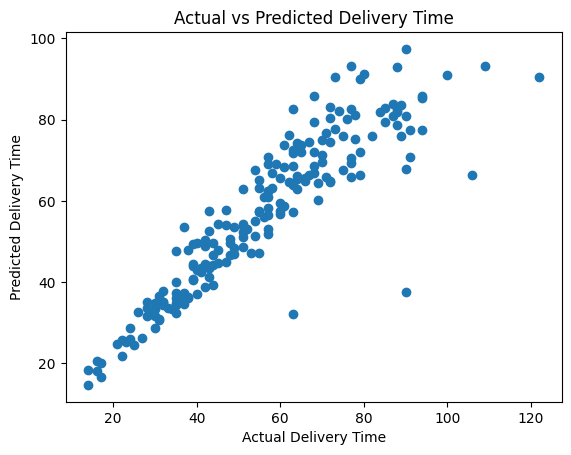

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")
plt.show()


In [ ]:
sample = X_test.iloc[0:1]
model.predict(sample)


array([35.07318042])

In [ ]:
import pickle

pickle.dump(
    {
        "model": model,
        "columns": X.columns.tolist()
    },
    open("food_delivery_model.pkl", "wb")
)

